<a href="https://colab.research.google.com/github/krixtofferxon/MyPython/blob/main/B2W1H_Word_Cloud_from_a_Wikipedia_Article.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Cloud from a Wikipedia Article


# Resources

* [Wikipedia](https://en.wikipedia.org/wiki/Main_Page)

* The official documentation for Python can be found [here](https://docs.python.org/3/).

* The Python documentation includes a [tutorial](https://docs.python.org/3/tutorial/index.html).

* Tutorial: [Part 3: An Informal Introduction to Python](https://docs.python.org/3/tutorial/introduction.html).

* Documentation for the Python `re` module can be found [here](https://docs.python.org/3/library/re.html).

* [regex101](https://regex101.com/) is a useful regex tester.

# Create a tokenizer

This is a function `tokenize` that takes a string and returns a list of tokens.

In [1]:
import string
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')

def tokenize(doc):
  # Remove punctuations
  no_punct = doc.translate(str.maketrans("", "", string.punctuation))
  tokens = word_tokenize(no_punct)
  # Remove prepositions, articles, and other words included in the stopwords
  # and add more words to the list of built in stopwords
  additional_stopwords = ['theyll', 'theyve', 'theyre', 'youll', 'youre', 'youve', 'couldnt']
  stopword_List = stopwords.words('english') + additional_stopwords

  filtered_tokens = [token for token in tokens if token.lower() not in stopword_List]
  return filtered_tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
print(stopwords.words('english'))


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

# Create a function to count frequencies

This is a function `count_frequencies` that takes a list of tokens and returns a dictionary that counts the number of times each token appeared in the list.

For example:

`count_frequencies(['hello','hello','world'])`

should return

`{'hello':2,'world':1}`.

In [3]:
from collections import defaultdict

def count_frequencies(tokens):
  # create a dictionary
  word_counts = defaultdict(int)
  # counts the instances of words in the dictionary
  for token in tokens:
    word_counts[token] += 1
  return dict(word_counts)

# Copy text from a Wikipedia article

Copy a Wikipedia article text and past it in the code cell below. This will store the text from that article in the variable `doc`.

In [4]:
doc = """
Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation via the off-side rule.34

Python is dynamically typed and garbage-collected. It supports multiple programming paradigms, including structured (particularly procedural), object-oriented and functional programming. It is often described as a "batteries included" language due to its comprehensive standard library.35 36

Guido van Rossum began working on Python in the late 1980s as a successor to the ABC programming language and first released it in 1991 as Python 0.9.0.37 Python 2.0 was released in 2000. Python 3.0, released in 2008, was a major revision not completely backward-compatible with earlier versions. Python 2.7.18, released in 2020, was the last release of Python 2.38

Python consistently ranks as one of the most popular programming languages.39 40 41 42

History

The designer of Python, Guido van Rossum, at OSCON 2006
Main article: History of Python
Python was conceived in the late 1980s43 by Guido van Rossum at Centrum Wiskunde & Informatica (CWI) in the Netherlands as a successor to the ABC programming language, which was inspired by SETL,44 capable of exception handling and interfacing with the Amoeba operating system.13 Its implementation began in December 1989.45 Van Rossum shouldered sole responsibility for the project, as the lead developer, until 12 July 2018, when he announced his "permanent vacation" from his responsibilities as Python's "benevolent dictator for life", a title the Python community bestowed upon him to reflect his long-term commitment as the project's chief decision-maker.46 In January 2019, active Python core developers elected a five-member Steering Council to lead the project.47 48

Python 2.0 was released on 16 October 2000, with many major new features such as list comprehensions, cycle-detecting garbage collection, reference counting, and Unicode support.49 Python 3.0, released on 3 December 2008, with many of its major features backported to Python 2.6.x50 and 2.7.x. Releases of Python 3 include the 2to3 utility, which automates the translation of Python 2 code to Python 3.51

Python 2.7's end-of-life was initially set for 2015, then postponed to 2020 out of concern that a large body of existing code could not easily be forward-ported to Python 3.52 53 No further security patches or other improvements will be released for it.54 55 Currently only 3.7 and later are supported. In 2021, Python 3.9.2 and 3.8.8 were expedited56 as all versions of Python (including 2.757 ) had security issues leading to possible remote code execution58 and web cache poisoning.59

In 2022, Python 3.10.4 and 3.9.12 were expedited60 and 3.8.13, and 3.7.13, because of many security issues.61 When Python 3.9.13 was released in May 2022, it was announced that the 3.9 series (joining the older series 3.8 and 3.7) would only receive security fixes in the future.62 On September 7, 2022, four new releases were made due to a potential denial-of-service attack: 3.10.7, 3.9.14, 3.8.14, and 3.7.14.63 64

As of November 2022, Python 3.11 is the stable release. Notable changes from 3.10 include increased program execution speed and improved error reporting.65

Design philosophy and features
Python is a multi-paradigm programming language. Object-oriented programming and structured programming are fully supported, and many of their features support functional programming and aspect-oriented programming (including metaprogramming66 and metaobjects).67 Many other paradigms are supported via extensions, including design by contract68 69 and logic programming.70

Python uses dynamic typing and a combination of reference counting and a cycle-detecting garbage collector for memory management.71 It uses dynamic name resolution (late binding), which binds method and variable names during program execution.

Its design offers some support for functional programming in the Lisp tradition. It has filter,mapandreduce functions; list comprehensions, dictionaries, sets, and generator expressions.72 The standard library has two modules (itertools and functools) that implement functional tools borrowed from Haskell and Standard ML.73

Its core philosophy is summarized in the document The Zen of Python (PEP 20), which includes aphorisms such as:74

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Readability counts.
Rather than building all of its functionality into its core, Python was designed to be highly extensible via modules. This compact modularity has made it particularly popular as a means of adding programmable interfaces to existing applications. Van Rossum's vision of a small core language with a large standard library and easily extensible interpreter stemmed from his frustrations with ABC, which espoused the opposite approach.43

Python strives for a simpler, less-cluttered syntax and grammar while giving developers a choice in their coding methodology. In contrast to Perl's "there is more than one way to do it" motto, Python embraces a "there should be one—and preferably only one—obvious way to do it" philosophy.74 Alex Martelli, a Fellow at the Python Software Foundation and Python book author, wrote: "To describe something as 'clever' is not considered a compliment in the Python culture."75

Python's developers strive to avoid premature optimization and reject patches to non-critical parts of the CPython reference implementation that would offer marginal increases in speed at the cost of clarity.76 When speed is important, a Python programmer can move time-critical functions to extension modules written in languages such as C; or use PyPy, a just-in-time compiler. Cython is also available, which translates a Python script into C and makes direct C-level API calls into the Python interpreter.

Python's developers aim for it to be fun to use. This is reflected in its name—a tribute to the British comedy group Monty Python77 —and in occasionally playful approaches to tutorials and reference materials, such as the use of the terms "spam" and "eggs" (a reference to a Monty Python sketch) in examples, instead of the often-used "foo" and "bar".78 79

A common neologism in the Python community is pythonic, which has a wide range of meanings related to program style. "Pythonic" code may use Python idioms well, be natural or show fluency in the language, or conform with Python's minimalist philosophy and emphasis on readability. Code that is difficult to understand or reads like a rough transcription from another programming language is called unpythonic.80 81
"""

# Generate a word cloud

Generate a word cloud from the Wikipedia article above.

In [5]:
# use your tokenizer to generate tokens
tokens = tokenize(doc)

In [6]:
# count frequencies using the function you built
frequencies = count_frequencies(tokens)

<Figure size 640x480 with 0 Axes>

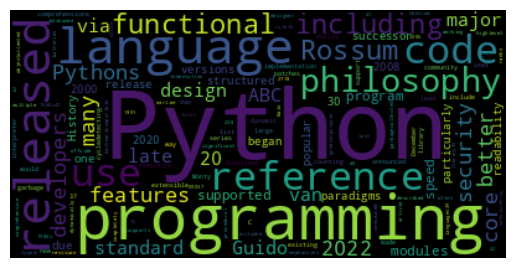

<Figure size 640x480 with 0 Axes>

In [7]:
# use this code to generate the word cloud
import wordcloud
cloud = wordcloud.WordCloud()
cloud.generate_from_frequencies(frequencies)
import matplotlib.pyplot as plt
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.figure()

# Discussion

Discussion of the results. Coming up of some ideas for improving the results. Trying to implement those ideas.

There are four (4) initial stages of text processing which are:
1. Tokenization
2. Normalization
3. Stemming
4. Stop Words

For this exercise, we are tasked to do tokenization to generate a word cloud. However, we can observe that words that are appearing bigger are the prepositions, articles, and punctuations since it's apparent that these are the most frequently used words in any article. But in a word cloud, we are more interested to show which buzzwords or “meaningful words” are the most frequently used. With this, we implement a code that removes stopwords and punctuation. The words in the list of default stopwords has also been extended, as well, to further improve the generated word cloud.

Further improvements that can be implemented are normalization and stemming so the program can handle words such as “run” and “running” or “Inc” and “Incorporated” and process/tally them as one word that will appear in the word cloud. Autocorrect can be implemented on next version, as well.


